In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Load model
with open("../models/lgbm_model.pkl", "rb") as f:
    lgb_model = pickle.load(f)

with open("../models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Load processed data
df = pd.read_csv("../data/processed_data.csv")
print(f"Loaded: {df.shape[0]:,} rows")
print(df.head(3))

Loaded: 1,852,394 rows
        cc_num    amt       category  is_fraud  hour  dayofweek  month  \
0  60416207185   7.27       misc_net         0    12          1      1   
1  60416207185  52.94  gas_transport         0     8          2      1   
2  60416207185  82.08  gas_transport         0     8          2      1   

   is_night  is_high_risk_merchant  is_high_amount  velocity_flag  risk_score  \
0         0                      1               0              0           1   
1         0                      0               0              0           0   
2         0                      0               0              0           0   

  risk_tier   unix_time  
0    MEDIUM  1325422035  
1       LOW  1325493897  
2       LOW  1325494056  


In [2]:
features = ['amt','hour','dayofweek','month','is_night',
            'is_high_risk_merchant','is_high_amount',
            'velocity_flag','risk_score']

X = df[features]

# Predict probability
df['lgb_risk_score'] = (lgb_model.predict_proba(X)[:,1] * 100).round(2)

# Map to risk tier based on score
df['ml_risk_tier'] = pd.cut(
    df['lgb_risk_score'],
    bins=[-1, 10, 30, 60, 101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL']
)

print("Risk score distribution:")
print(df['lgb_risk_score'].describe().round(2))
print("\nML Risk tier distribution:")
print(df['ml_risk_tier'].value_counts())

Risk score distribution:
count    1852394.00
mean           6.27
std           18.23
min            0.00
25%            0.02
50%            0.09
75%            1.22
max           99.99
Name: lgb_risk_score, dtype: float64

ML Risk tier distribution:
ml_risk_tier
LOW         1628809
MEDIUM        87704
CRITICAL      74452
HIGH          61429
Name: count, dtype: int64


In [3]:
print("Fraud rate per ML risk tier:")
print(df.groupby('ml_risk_tier')['is_fraud']
        .agg(['sum','count','mean'])
        .rename(columns={'sum':'fraud_cases','count':'total','mean':'fraud_rate'})
        .assign(fraud_rate=lambda x: (x['fraud_rate']*100).round(3))
        .sort_values('fraud_rate', ascending=False))

Fraud rate per ML risk tier:
              fraud_cases    total  fraud_rate
ml_risk_tier                                  
CRITICAL             9202    74452      12.360
HIGH                  330    61429       0.537
MEDIUM                 68    87704       0.078
LOW                    51  1628809       0.003


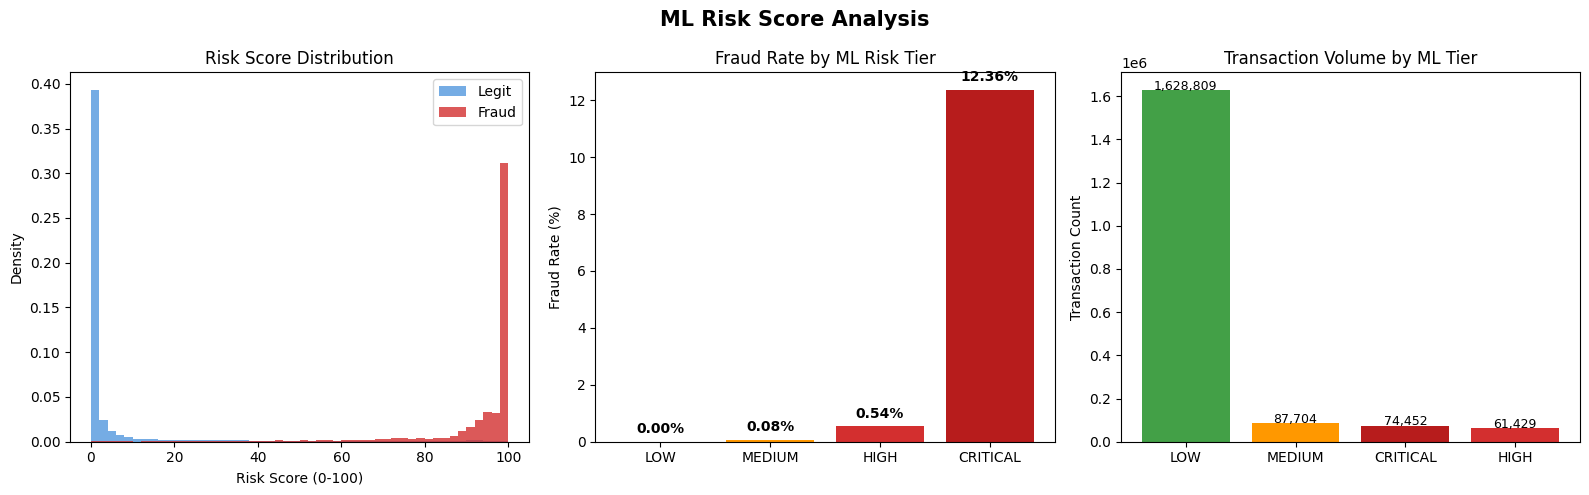

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ML Risk Score Analysis', fontsize=15, fontweight='bold')

# Chart 1: Score distribution
axes[0].hist(df[df['is_fraud']==0]['lgb_risk_score'], 
             bins=50, alpha=0.6, color='#1976d2', label='Legit', density=True)
axes[0].hist(df[df['is_fraud']==1]['lgb_risk_score'], 
             bins=50, alpha=0.8, color='#d32f2f', label='Fraud', density=True)
axes[0].set_xlabel('Risk Score (0-100)')
axes[0].set_ylabel('Density')
axes[0].set_title('Risk Score Distribution')
axes[0].legend()

# Chart 2: Fraud rate by ML tier
tier_stats = df.groupby('ml_risk_tier')['is_fraud'].mean() * 100
tier_colors = {'LOW':'#43a047','MEDIUM':'#ff9800','HIGH':'#d32f2f','CRITICAL':'#b71c1c'}
bars = axes[1].bar(tier_stats.index, tier_stats.values,
                   color=[tier_colors[t] for t in tier_stats.index])
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by ML Risk Tier')
for bar, val in zip(bars, tier_stats.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.3, f"{val:.2f}%",
                ha='center', fontweight='bold')

# Chart 3: Volume by tier
tier_counts = df['ml_risk_tier'].value_counts()
axes[2].bar(tier_counts.index, tier_counts.values,
            color=[tier_colors[t] for t in tier_counts.index])
axes[2].set_ylabel('Transaction Count')
axes[2].set_title('Transaction Volume by ML Tier')
for i, (idx, val) in enumerate(tier_counts.items()):
    axes[2].text(i, val + 1000, f"{val:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/04_risk_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Save final scored dataset
output_cols = ['cc_num','amt','category','hour','is_fraud',
               'is_night','is_high_risk_merchant','is_high_amount',
               'velocity_flag','risk_score','risk_tier',
               'lgb_risk_score','ml_risk_tier']

output_cols = [c for c in output_cols if c in df.columns]
df[output_cols].to_csv("../data/risk_scores_full.csv", index=False)

print(f"Saved risk_scores_full.csv — {df.shape[0]:,} rows")
print(f"\nTop 10 highest risk transactions:")
print(df[df['is_fraud']==1][['amt','lgb_risk_score','ml_risk_tier','category']]
        .sort_values('lgb_risk_score', ascending=False)
        .head(10).to_string(index=False))

Saved risk_scores_full.csv — 1,852,394 rows

Top 10 highest risk transactions:
    amt  lgb_risk_score ml_risk_tier     category
 886.21           99.99     CRITICAL shopping_net
 843.58           99.99     CRITICAL shopping_net
 796.29           99.99     CRITICAL     misc_net
 799.22           99.99     CRITICAL     misc_net
1062.26           99.99     CRITICAL shopping_net
 828.49           99.99     CRITICAL     misc_net
1012.77           99.99     CRITICAL shopping_net
 912.26           99.99     CRITICAL shopping_net
 307.70           99.99     CRITICAL  grocery_pos
 300.21           99.99     CRITICAL  grocery_pos
